In [106]:
import requests
import os
import datetime as dt
import json
from dotenv import load_dotenv
from google.cloud import storage
from google.cloud import bigquery 
import geopandas as gpd
import pandas as pd
import numpy as np

In [46]:
load_dotenv()

True

In [ ]:
#pull a representative json from our bucket to inspect
bucket_name = os.environ.get("GCS_BUCKET_NAME")
service_acct = os.environ.get("GCS_BUCKET_CREDENTIALS")

client = storage.Client.from_service_account_json(service_acct)
bucket = client.bucket(bucket_name)

In [48]:
query_date = '2026-06-09'
blob = bucket.blob(f'{query_date}_311_api_call')
json_string = blob.download_as_text()
june09 = json.loads(json_string)

Regional Access Boundary HTTP request failed after retries: response_data={'error': {'code': 400, 'message': 'Precondition check failed.', 'status': 'FAILED_PRECONDITION'}}, retryable_error=False


In [49]:
june09

[{'service_request_id': '101004214056',
  'requested_datetime': '2026-06-08T19:11:11.000',
  'updated_datetime': '2026-06-09T00:52:18.000',
  'status_description': 'Open',
  'status_notes': 'in progress',
  'agency_responsible': 'PW - Street and Environmental Services',
  'service_name': 'Street and Sidewalk Cleaning',
  'service_subtype': 'garbage_and_debris',
  'service_details': 'human_waste_or_urine',
  'address': '302 12TH ST, SAN FRANCISCO, CA 94103',
  'street': '12TH ST',
  'supervisor_district': '6.0',
  'neighborhoods_sffind_boundaries': 'South of Market',
  'analysis_neighborhood': 'Mission',
  'police_district': 'SOUTHERN',
  'lat': '37.77079234085467',
  'long': '-122.41498643374592',
  'point': {'latitude': '37.77079234085467',
   'longitude': '-122.41498643374592',
   'human_address': '{"address": "", "city": "", "state": "", "zip": ""}'},
  'point_geom': {'type': 'Point',
   'coordinates': [-122.414986434, 37.770792341]},
  'source': 'Mobile',
  'media_url': {'url': 'ht

In [76]:
#see if the geometry can load in right (thus gdf ATTEMPT)
gdf_attempt = gpd.GeoDataFrame(june09)
gdf_attempt.head()

,service_request_id,requested_datetime,updated_datetime,status_description,status_notes,agency_responsible,service_name,service_subtype,service_details,address,...,police_district,lat,long,point,point_geom,source,media_url,data_as_of,data_loaded_at,closed_date
0,101004214056,2026-06-08T19:11:11.000,2026-06-09T00:52:18.000,Open,in progress,PW - Street and Environmental Services,Street and Sidewalk Cleaning,garbage_and_debris,human_waste_or_urine,"302 12TH ST, SAN FRANCISCO, CA 94103",...,SOUTHERN,37.77079234085467,-122.41498643374592,"{'latitude': '37.77079234085467', 'longitude':...","{'type': 'Point', 'coordinates': [-122.4149864...",Mobile,{'url': 'https://spot-sf-res.cloudinary.com/im...,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,NaN
1,101004214794,2026-06-09T00:22:00.000,2026-06-09T01:04:59.000,Closed,Case Resolved - Officer responded to request u...,MTA - Parking Enforcement Dispatch,Parking Enforcement,parking_on_sidewalk,NaN,"3539 24TH ST, SAN FRANCISCO, CA 94110",...,MISSION,37.75187577,-122.42230363,"{'latitude': '37.75187577', 'longitude': '-122...","{'type': 'Point', 'coordinates': [-122.4223036...",Web,NaN,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,2026-06-09T02:04:56.000
2,101004214762,2026-06-08T23:37:47.000,2026-06-09T01:23:33.000,Closed,Case Resolved - Officer responded to request u...,MTA - Parking Enforcement Dispatch,Parking Enforcement,parking_on_sidewalk,NaN,"859 ELIZABETH ST, SAN FRANCISCO, CA 94114",...,MISSION,37.75163311952114,-122.43985857814549,"{'latitude': '37.75163311952114', 'longitude':...","{'type': 'Point', 'coordinates': [-122.4398585...",Mobile,NaN,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,2026-06-09T02:23:30.000
3,101000858880,2024-10-14T10:01:48.000,2026-06-09T01:37:18.000,Open,accepted,PW - Street Use and Mapping,Street Defect,sidewalk_defect,collapsed_sidewalk,"343 BRIDGEVIEW DR, SAN FRANCISCO, CA 94124",...,BAYVIEW,37.73256428,-122.39843417,"{'latitude': '37.73256428', 'longitude': '-122...","{'type': 'Point', 'coordinates': [-122.3984341...",Phone,NaN,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,NaN
4,101003520129,2026-02-18T10:20:05.000,2026-06-09T01:37:21.000,Open,accepted,PW - Street Use and Mapping,Sidewalk and Curb,missing_side_sewer_vent_cover,NaN,"464 MINNA ST, SAN FRANCISCO, CA 94103",...,SOUTHERN,37.781154665582136,-122.40748599171638,"{'latitude': '37.781154665582136', 'longitude'...","{'type': 'Point', 'coordinates': [-122.4074859...",Mobile,{'url': 'https://spot-sf-res.cloudinary.com/im...,2026-06-11T01:00:00.000,2026-06-11T03:13:25.000,NaN


AttributeError: The CRS attribute of a GeoDataFrame without an active geometry column is not defined. Use GeoDataFrame.set_geometry to set the active geometry column.

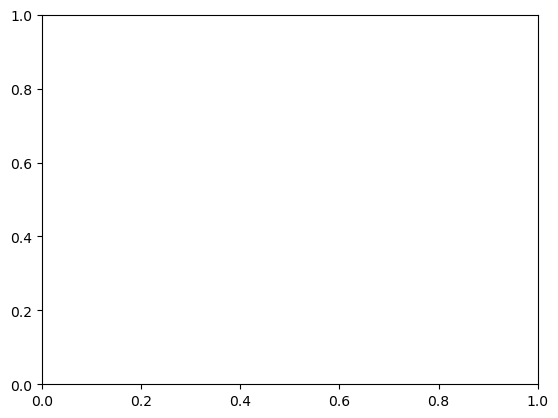

In [ ]:
gdf_attempt.plot() #lol it does not, that's okay we move on

In [ ]:
#inspect columns
for c in gdf_attempt.columns:
    print(c)

service_request_id
requested_datetime
updated_datetime
status_description
status_notes
agency_responsible
service_name
service_subtype
service_details
address
street
supervisor_district
neighborhoods_sffind_boundaries
analysis_neighborhood
police_district
lat
long
point
point_geom
source
media_url
data_as_of
data_loaded_at
closed_date


In [ ]:
#format list of neighborhoods
neighborhoods =  gdf_attempt['neighborhoods_sffind_boundaries'].str.lower().dropna().unique()

In [ ]:
#bring in our canonical neighborhoods
BQclient = bigquery.Client()
query = '''SELECT * 
           FROM `neighboorhood-nachos.neighborhood_livability_data.neighborhoods`'''
df_canonical_neighborhoods = BQclient.query(query).to_dataframe()
df_canonical_neighborhoods.head()

,id,name,geometry
0,1,Seacliff,MULTIPOLYGON (((-122.49345526799993 37.7835181...
1,2,Lake Street,MULTIPOLYGON (((-122.48715071499993 37.7837854...
2,3,Presidio National Park,MULTIPOLYGON (((-122.47758017099994 37.8109931...
3,4,Presidio Terrace,MULTIPOLYGON (((-122.47241052999993 37.7873465...
4,5,Inner Richmond,MULTIPOLYGON (((-122.47262578999994 37.7863148...


In [78]:
#format into good list
canonical_neighborhoods = df_canonical_neighborhoods['name']
canonical_neighborhoods = [x.lower() for x in canonical_neighborhoods]

In [ ]:
#Compare!
for n in neighborhoods:
    if n not in canonical_neighborhoods:
        print(n)

st. mary's park
fisherman's wharf


In [75]:
canonical_neighborhoods

['seacliff',
 'lake street',
 'presidio national park',
 'presidio terrace',
 'inner richmond',
 'sutro heights',
 'lincoln park / ft. miley',
 'outer richmond',
 'golden gate park',
 'presidio heights',
 'laurel heights / jordan park',
 'lone mountain',
 'anza vista',
 'cow hollow',
 'union street',
 'nob hill',
 'marina',
 'telegraph hill',
 'downtown / union square',
 'tenderloin',
 'civic center',
 'hayes valley',
 'alamo square',
 'panhandle',
 'haight ashbury',
 'lower haight',
 'mint hill',
 'duboce triangle',
 'cole valley',
 'rincon hill',
 'south beach',
 'south of market',
 'showplace square',
 'mission bay',
 'yerba buena island',
 'treasure island',
 'mission dolores',
 'castro',
 'outer sunset',
 'parkside',
 'stonestown',
 'parkmerced',
 'lakeshore',
 'golden gate heights',
 'forest hill',
 'west portal',
 'clarendon heights',
 'midtown terrace',
 'laguna honda',
 'lower nob hill',
 'upper market',
 'dolores heights',
 'mission',
 'potrero hill',
 'dogpatch',
 'central w

In [89]:
# st.mary's square and fisherman's wharf exist as st. marys square and fishermans warf, rip, let's see what we wanna do about that
neighborhoods_formatted = []
for n in neighborhoods:
    neighborhoods_formatted.append(n.replace("'",""))
for n in neighborhoods_formatted:
    if n not in canonical_neighborhoods:
        print(n)

In [114]:
df_canonical_neighborhoods['name'] = df_canonical_neighborhoods['name'].str.lower()

In [121]:
df_canonical_neighborhoods.set_index('name').loc['seacliff', 'id']

1

In [127]:
neighborhood_id = []
for n in gdf_attempt['neighborhoods_sffind_boundaries'].str.lower():
    if type(n) == str:
        n = n.replace("'", "")
        neighborhood_id.append(df_canonical_neighborhoods.set_index('name').loc[n, 'id'])
    else:
        neighborhood_id.append(np.nan)

In [131]:
for id in neighborhood_id:
    if id == np.nan:
        print(id)

In [132]:
len(neighborhood_id)

7941

In [133]:
len(gdf_attempt['neighborhoods_sffind_boundaries'])

7941

In [134]:
gdf_attempt['neighborhood_id'] = neighborhood_id

In [136]:
gdf = gpd.GeoDataFrame(gdf_attempt, geometry=gpd.points_from_xy(gdf_attempt['long'], gdf_attempt['lat']), crs='EPSG:4326')

<Axes: >

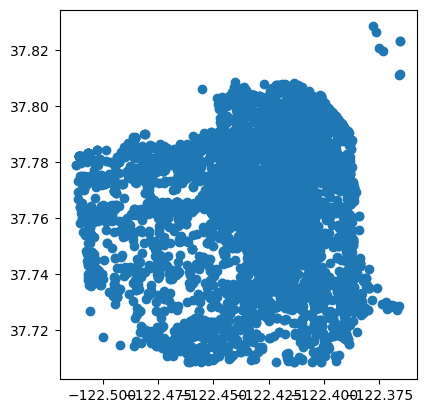

In [137]:
gdf.plot()

In [138]:
for c in gdf.columns:
    print(c)

service_request_id
requested_datetime
updated_datetime
status_description
status_notes
agency_responsible
service_name
service_subtype
service_details
address
street
supervisor_district
neighborhoods_sffind_boundaries
analysis_neighborhood
police_district
lat
long
point
point_geom
source
media_url
data_as_of
data_loaded_at
closed_date
neighborhood_id
geometry


In [139]:
gdf_needed_cols = ['311_incident_id', 'neighborhood_id', 'police_district_id', 'requested_datetime',
                   'updated_datetime', 'closed_datetime', 'status_description', 'status_notes',
                   'agency_responsible', 'service_name', 'service_subtype', 'service_details', 'supervisor_district',
                   'lat', 'long', 'geometry', 'source', 'media_url']

In [151]:
gdf ['closed_datetime'] = gdf['closed_date'].copy()

In [152]:
gdf ['311_incident_id'] = gdf['service_request_id'].copy()

In [147]:
gdf_formatted = gdf[gdf_needed_cols]
gdf_formatted.head()

KeyError: "['police_district_id', 'closed_datetime'] not in index"